# Assignment 3: Reinforcement Learning

**Goal**: Get familiar with a reinforcement learning approach to solve multi-armed bandit problem.

**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

We will implement a value-based reinforcement learning approach with two
algorithm variations: epsilon-greedy (e-greedy) and upper confidence bound
(UCB) algorithms and perform an analysis on their behavior.

Please answer the `Questions` and implement coding `Tasks` by filling **PLEASE FILL IN** sections. *Documentation* of your code is also important. You can find the grading scheme in implementation cells.

## 1. Introduction: Multi-Armed Bandit Problem

Imagine you are in a casino facing a row of slot machines, say there are 20 of them. Each slot machine is providing reward based on a certain probability distribution that is unknown to you.

This is your first time in this casino, thus you have no idea what to do next. You have just enough money to play for 100 times and each of these times, you can pick any machine you want and after "pulling"

What would you do?

The overall goal would of course be to find out the one that is providing the most reward, right? What should your algorithm be to get the most reward at the end?

## 2. Implementation

In [1]:
%%python -m pip install --upgrade pip
%pip install "matplotlib>=3.7" "numpy>=1.25" "tqdm>=4.65" ipywidgets --user

In [2]:
%pip install "matplotlib>=3.7" "numpy>=1.25" "tqdm>=4.65" --upgrade --user

Note: you may need to restart the kernel to use updated packages.


In [3]:
%matplotlib inline

In [4]:
# First import the dependencies
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

**Question 1 (0-0.25-0.5pt):** Please write down mathematical expressions arm selection for the e-greedy and UCB algorithms and discuss their parameters.

**Answer:**
```
e-greedy = { argmax_a(Q_t(a)),  if(rand < 1-e) \
             rand(a),           otherwise

UCB ~ A_t = argmax_a[Q_t(a) + c sqrt(ln(t)/N_t(a))]
```
e-greedy parameters: epsilon in [0,1]: exploration probability, the higher e the more exploration and slower exploitation \

UCB parameters: \
c > 0: exploration strength (higher c = more exploration) \
t: current time step \
N_t(a): number of times arm a has been selected \
Q_t(a): estimated mean reward for arm a \

---

**Task 1 (3 pt):** Please implement the e-greedy and UCB algorithms in the code given below.

In [5]:
#################################
# Grading
# 0 pts if the code does not work, code works but it is fundamentally incorrect
# 0.75 pts if the code works but some functions are incorrect and it is badly explained
# 1.5 pts if the code works but some functions are incorrect but it is explained well
# 2.25 pts if the code works very well aligned with the task without any mistakes, but it is badly explained
# 3 pts if the code works very well aligned with the task without any mistakes, and it is well explained
################################################################


# ============ PLEASE DO NOT CHANGE ============ #


def initialize(n_arms):
    rng = np.random.default_rng()
    R = rng.uniform(low=0.45, high=0.55, size=n_arms)
    R[rng.integers(n_arms)] = 0.9
    # return actual mean of the reward probabilities
    return R


# ================================================ #


# the epsilon-greedy algorithm (ignore kwargs)
def e_greedy(Q, epsilon, **kwargs):
    """
    e-greedy algorithm
    explore by choosing a random arm uniformly or
    exploit by choosing the arm with the highest current estimated value Q[a]

    :param Q: np.array -- value estimates for each arm
    :param epsilon: float -- exploration rate in [0, 1]

    :return: int -- the selected arm
    """
    ########### PLEASE FILL IN ##############
    # explore with prob epsilon, otherwise exploit
    if np.random.rand() < epsilon:
        selection = np.random.randint(len(Q))
    else:
        selection = int(np.argmax(Q))
    #########################################
    return selection


# The upper confidence bound algorithm (ignore kwargs)
def UCB(Q, selection_counter, t, **kwargs):
    """
    UCB algorithm selection
    Selects the arm maximizing: UCB[a] = Q[a] + C * sqrt(log(t + 1)/N[a])

    - Q[a] is the current estimated mean reward of arm a
    - N[a] is the number of times arm a has been selected so far
    - t is the current time ste
    - C controls exploration strength

    :param Q: np.array -- value estimates for each arm
    :param selection_counter: np.array -- counts N[a] for each arm.
    :param t: int -- time

    :return: int -- the selected arm
    """

    C = 0.5  # Parameter (keep it constant)
    ########### PLEASE FILL IN ##############
    # every arm is selected at least once and avoid divide by zero error
    for a in range(len(Q)):
        if selection_counter[a] == 0:
            return a

    ucb_values = Q + C * np.sqrt(np.log(t + 1) / selection_counter)  # meximize this function
    selection = int(np.argmax(ucb_values))
    #########################################
    return selection


def MAB(
    trials,  # total number of arm pulls
    n_arms,  # number of arms to pull
    epsilon,  # exploration parameter for the epsilon-greedy algorithm
    alpha,  # learning rate for updating Q-values
    init,  # initial starting value of the Q-values
    algorithm,  # the type of update: e_greedy or UCB
):
    # ============ PLEASE DO NOT CHANGE ============ #
    # initialization of the reward distributions unknown to the player
    R = initialize(n_arms)
    cumulative_reward_trend = np.zeros(trials)
    selection_trend = np.zeros(trials)
    reward_trend = np.zeros(trials)
    cumulative_reward = 0

    # initialize counter of selection for each arms
    selection_counter = np.zeros(n_arms)

    # initialize initial estimates of rewards
    Q = np.ones(n_arms) * init
    # ================================================ #

    for i in trange(trials, leave=False):
        # ============ PLEASE DO NOT CHANGE ============ #
        # select an arm to pull based on reward estimates and other
        kwargs = {
            "Q": Q,
            "epsilon": epsilon,
            "selection_counter": selection_counter,
            "t": i,
        }
        selection = algorithm(**kwargs)
        reward = np.random.normal(R[selection], 0.01)
        # ================================================ #

        ########### PLEASE FILL IN ##############
        # Update Q values
        Q[selection] = Q[selection] + alpha * (reward - Q[selection])
        ########################################

        # ============ PLEASE DO NOT CHANGE ============ #
        reward_trend[i] = reward
        selection_trend[i] = selection
        selection_counter[selection] += 1
        cumulative_reward += reward
        cumulative_reward_trend[i] = cumulative_reward
        # ================================================ #

    return reward_trend

**Question 2 (0-0.25-0.5pt):** Please explain the concept of exploration and exploitation in the context epsilon-greedy and UCB algorithm contexts.
How does the epsilon-greedy algorithm balance exploration and exploitation?


**Answer:** The e-greedy algorithm balances exploration and exploitation using a fixed probability parameter epsilon between 0 and 1 \
 \
UCB balances exploration and exploitation differently. Instead of random exploration, it selects the arm that maximizes its function. Arms selected fewer times (smaller N_t(a)) receives a larger exploration bonus. As an arm is sampled more often, the bonus shrinks. UCB explores systematically based on uncertainty rather than randomly. It automatically reduces exploration over time.

---

## 3. Algorithm Analysis

In [6]:
# ============ PLEASE DO NOT REMOVE ============ #
def plot_experiments(experiment1, experiment2, labels):
    experiment1 = np.array(experiment1)
    experiment1_std = np.std(experiment1, axis=0)
    experiment1_mean = np.mean(experiment1, axis=0)

    experiment2 = np.array(experiment2)
    experiment2_std = np.std(experiment2, axis=0)
    experiment2_mean = np.mean(experiment2, axis=0)

    mean = [experiment1_mean, experiment2_mean]
    std = [experiment1_std, experiment2_std]

    plt.figure(figsize=(12, 6))
    y_values = np.arange(0, len(mean[0]))
    for i in range(len(mean)):
        plt.plot(y_values, mean[i], label=labels[i])
        plt.fill_between(y_values, mean[i] + std[i], mean[i] - std[i], alpha=0.2)

    plt.xlabel("Arm pulls (trials)")
    plt.ylabel("Average reward of 20 runs")

    plt.legend()


# ================================================ #

## 2. Comparison of e-greedy and UCB algorithms

Running the code below will launch all the experiments that we would like to plot and perform analysis on.

In [7]:
experiment1 = []  # epsilon greedy epsilon: 0.1 initial Q: 0
experiment2 = []  # epsilon greedy epsilon: 0.1 initial Q: 1
experiment3 = []  # epsilon greedy epsilon: 0.2 initial Q: 0

experiment4 = []  # UCB initial Q: 0
experiment5 = []  # UCB initial Q: 1

for _ in trange(20):
    # MAB(trials, n_arms, epsilon, alpha, init, algorithm)
    experiment1.append(MAB(5_000, 20, 0.1, 0.1, 0, e_greedy))
    experiment2.append(MAB(5_000, 20, 0.1, 0.1, 1, e_greedy))
    experiment3.append(MAB(5_000, 20, 0.2, 0.1, 0, e_greedy))

    experiment4.append(MAB(5_000, 20, 0.1, 0.1, 0, UCB))
    experiment5.append(MAB(5_000, 20, 0.1, 0.1, 1, UCB))

---
**Question 3 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy and UCB algorithms for initial Q: 0 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:** \
Early phase: \
UCB performs better. It forces the exploration of all arms using the confidence term, so it quickly identifies the optimal arm. e-greedy explores randomly and is taking longer to discover the best arm. \
 \
Middle phase: \
UCB continues outperforming because exploration decreases naturally as uncertainty shrinks. e-greedy still explores with fixed probability epsilon, which slows convergence. \
 \
Late phase: \
UCB remains slightly better. e-greedy keeps exploring with probability epsilon, so its average reward stays slightly lower due to unnecessary exploration.

Winner UCB Q=0

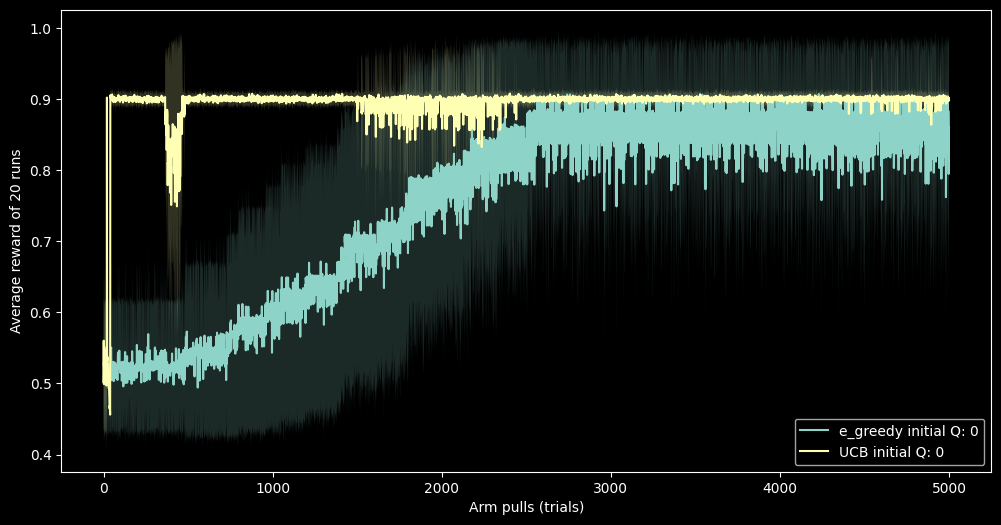

In [8]:
label = ["e_greedy initial Q: 0", "UCB initial Q: 0"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment1,   # e_greedy initial Q: 0
    experiment4,   # UCB initial Q: 0
    ########################################
    label,
)

---
**Question 4 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy and UCB algorithms for initial Q: 1 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:** \
Early phase: \
Both converge very fast, but UCB seems more uncertain than e-greedy. \
 \
Middle phase: \
UCB becomes more stable and E-greedy is wasting cost on exploration each time t. \
 \
Late phase: \
UCB slightly outperforms because exploration decreases automatically, while e-greedy keeps exploring at constant rate.

e-greedy Q=1 wins early, but UCB Q=1 is overall better

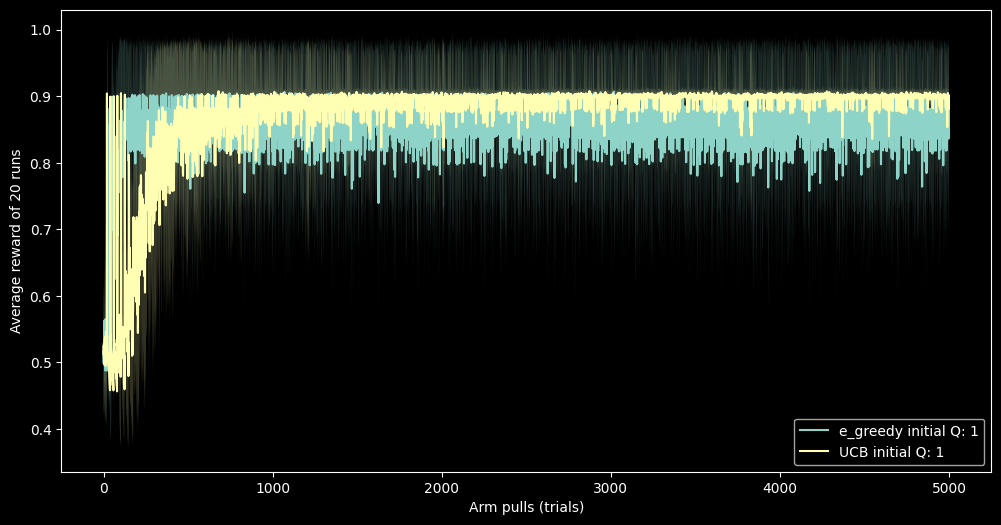

In [9]:
label = ["e_greedy initial Q: 1", "UCB initial Q: 1"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment2,
    experiment5,
    ########################################
    label,
)

---
**Question 5 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy for initial Q: 0 for epsilon values 0.1 and 0.2 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:** \
Early phase: \
e = 0.2 performs better because more exploration helps find the optimal arm faster. \
 \
Middle phase: \
e = 0.1 catches up as exploitation becomes more important. \
 \
Late phase: \
e = 0.1 performs better because e = 0.2 continues excessive exploration, lowering long-term reward.

e-greedy 0.1 wins because of higher average

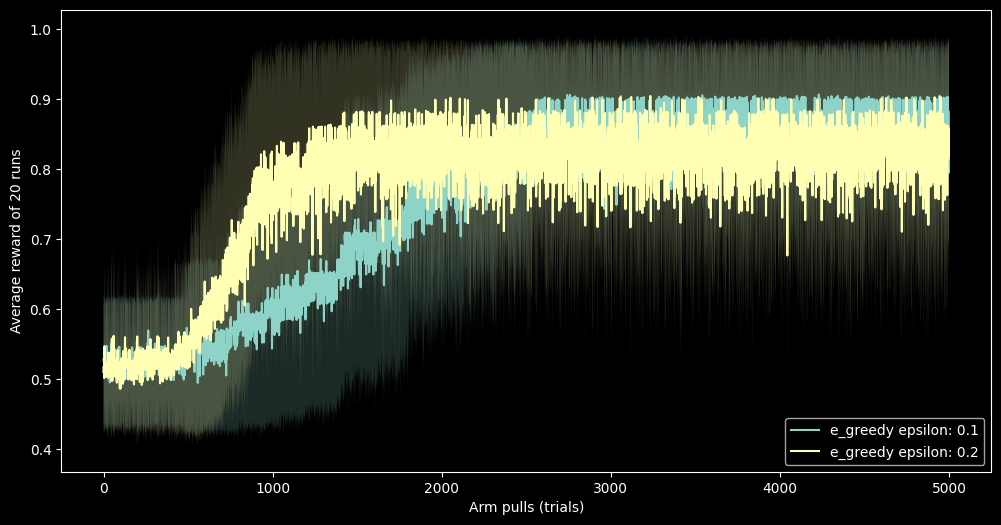

In [10]:
label = ["e_greedy epsilon: 0.1", "e_greedy epsilon: 0.2"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment1,
    experiment3,
    ########################################
    label,
)

---
**Question 6 (0-0.5-1pt):** Plot and compare the average rewards for e-greedy for epsilon = 0.1 initial Q: 0 and 1 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:** \
Early phase: \
Initial Q = 1 performs much better due to the optimistic initialization, which encourages exploration of all arms. \
 \
Middle phase: \
Initial Q = 1 converges faster because early exploration helped identify the optimal arm sooner. \
 \
Late phase: \
Both become similar on average with no clear winner. \

e-greedy Q=1 wins because of faster convergance

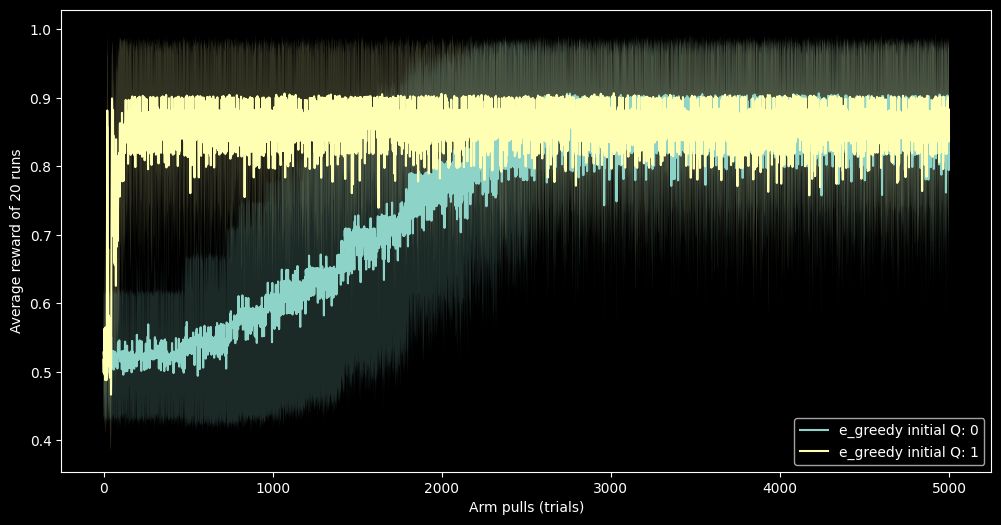

In [11]:
label = ["e_greedy initial Q: 0", "e_greedy initial Q: 1"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment1,
    experiment2,
    ########################################
    label,
)

---
**Question 7 (0-0.5-1pt):** Plot and compare the average rewards for UCB initial Q: 0 and 1 in different period of the process.

Please discuss in each phase of the process, which algorithm worked better and why?

**Answer:** \
Early phase: \
Similar performance but Q=0 initialization converges faster and more consistently. \
 \
Middle phase: \
UCB Q=0 is still more consistent. \
 \
Late phase: \
Nearly identical performance but Q=0 is still more consistent overall. \

UCB Q=0 wins because of higher average/more consistent

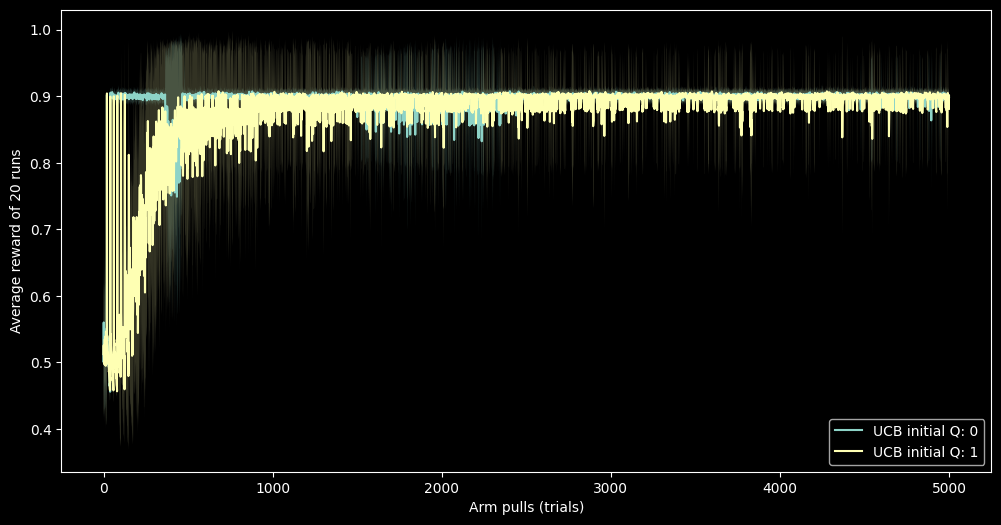

In [12]:
label = ["UCB initial Q: 0", "UCB initial Q: 1"]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment4,
    experiment5,
    ########################################
    label,
)

---

## 3. Final remarks

**Question 8 (0-0.5-1pt):** Based on the all plots and analysis, please plot the best and worst performing algorithms and discuss the comparison? Discuss why that may be the case.

**Answer:** \
Best: UCB  Q=0 \
Worst: e-greedy (e = 0.2, initial Q = 0) \

UCB performs best because exploration decreases naturally over time, it balances uncertainty and reward optimally and it avoids constant random exploration but specific Q=0 seemed like it converges faster then Q=1 and its average is higher than Q=1.

The worst performer e-greedy 0.2 suffers from too much exploration in late stages and lower exploitation of the optimal arm.

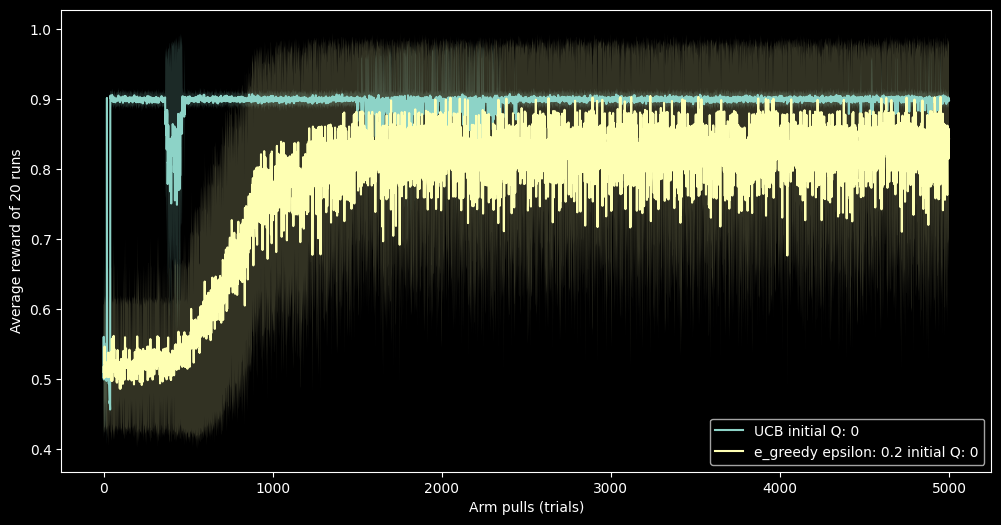

In [13]:
# PLOT THE BEST AND WORST PERFORMING ALGORITHMS AND COMPARE
label = [
    ########### PLEASE FILL IN ##############
    "UCB initial Q: 0",
    "e_greedy epsilon: 0.2 initial Q: 0",
    ########################################
]
plot_experiments(
    ########### PLEASE FILL IN ##############
    experiment4,  # UCB Q=0
    experiment3,  # epsilon greedy 0.2
    ########################################
    label,
)